# 02 — Semantic Retrieval
**CLPapersAIAgent | Member 2**

This notebook addresses the key limitation of TF-IDF (D1): it only matches exact words and misses semantic meaning.

For example, TF-IDF cannot match:
- Query: `deep learning` → Paper about `neural networks`
- Query: `language model` → Paper about `GPT`

This notebook fixes that by:
1. Loading chunks from MongoDB (prepared in notebook 01)
2. Generating dense embeddings using sentence-transformers
3. Storing embeddings in Qdrant vector database
4. Building a hybrid search (BM25 lexical + dense semantic)
5. Comparing results against the TF-IDF baseline

## Setup

In [6]:
import sys, os
sys.path.append(os.path.abspath(".."))

import json
import time
import numpy as np
from pathlib import Path
from pymongo import MongoClient
from qdrant_client import QdrantClient
from qdrant_client.models import (
    Distance, VectorParams, PointStruct
)
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['axes.facecolor']   = '#161b22'
matplotlib.rcParams['text.color']       = '#e6edf3'
matplotlib.rcParams['axes.labelcolor']  = '#8b949e'
matplotlib.rcParams['xtick.color']      = '#8b949e'
matplotlib.rcParams['ytick.color']      = '#8b949e'

print('All imports OK')

/Users/maryamalsuwaidi/Documents/GitHub/CLPapersAIAgent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


In [ ]:
# Install required packages if not already installed
# Run this cell once if you get ModuleNotFoundError
# !pip install sentence-transformers qdrant-client rank-bm25

## Step 1 — Load Chunks from MongoDB
We retrieve all chunks stored by Member 1's ingestion pipeline. Each chunk contains the text, paper metadata, and page attribution.

In [7]:
# Connect to MongoDB
mongo_client = MongoClient('mongodb://localhost:27017/')
db = mongo_client['clpapers']

# Load all chunks
chunks = list(db.chunks.find({}, {'_id': 0}))
print(f'Loaded {len(chunks)} chunks from MongoDB')
print(f'Unique papers: {len(set(c["paper_id"] for c in chunks))}')
print('\nSample chunk keys:', list(chunks[0].keys()))

Loaded 6728 chunks from MongoDB
Unique papers: 208

Sample chunk keys: ['chunk_id', 'paper_id', 'chunk_index', 'start_word', 'end_word', 'word_count', 'page_start', 'page_end', 'text', 'title', 'authors', 'year']


## Step 2 — Generate Dense Embeddings
We use `all-MiniLM-L6-v2` from sentence-transformers. This model converts text into 384-dimensional vectors where semantically similar texts are close together in vector space.

Unlike TF-IDF which counts word frequencies, this model understands **meaning** — so `neural networks` and `deep learning` will have similar vector representations.

In [8]:
print('Loading sentence-transformer model...')
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'Model loaded. Embedding dimension: {model.get_sentence_embedding_dimension()}')

Loading sentence-transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6605.61it/s]


Model loaded. Embedding dimension: 384


/var/folders/6w/15st5p1540n960x3sj60nfz80000gn/T/ipykernel_79816/3762602099.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Model loaded. Embedding dimension: {model.get_sentence_embedding_dimension()}')


In [9]:
# Extract texts for embedding
texts = [c['text'] for c in chunks]
chunk_ids = [c['chunk_id'] for c in chunks]

print(f'Generating embeddings for {len(texts)} chunks...')
t0 = time.time()

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

elapsed = round(time.time() - t0, 2)
print(f'\nEmbeddings generated in {elapsed}s')
print(f'Embedding matrix shape: {embeddings.shape}')

Generating embeddings for 6728 chunks...


Batches: 100%|██████████| 211/211 [00:37<00:00,  5.70it/s]


Embeddings generated in 37.04s
Embedding matrix shape: (6728, 384)


### Plot: Embedding Space Visualization (PCA)
We reduce 384 dimensions to 2D using PCA to visualize how chunks cluster by paper.

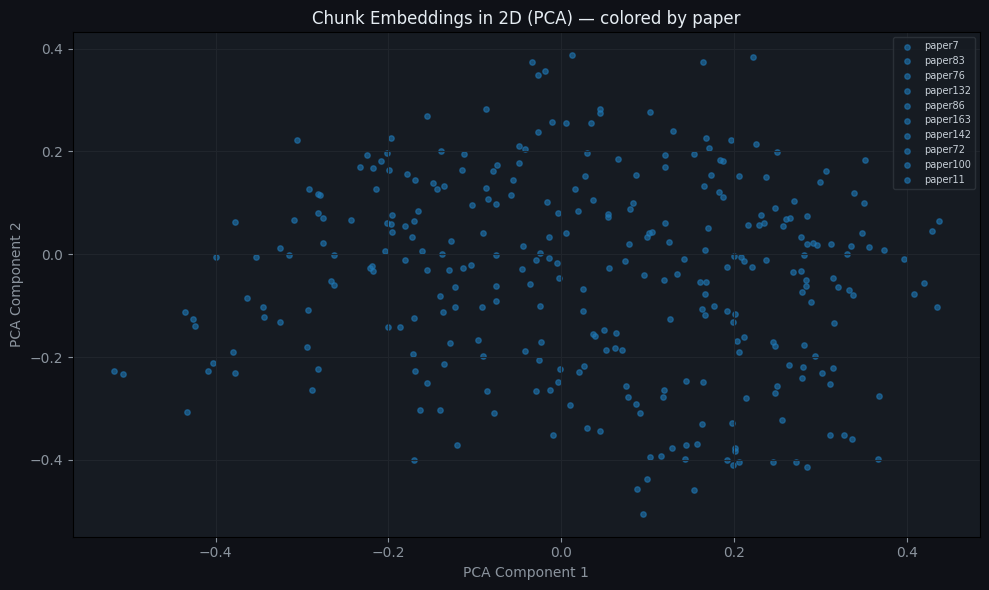

Plot saved.


In [11]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Color by paper
paper_ids = [c['paper_id'] for c in chunks]
unique_papers = list(set(paper_ids))
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_papers)))
paper_color_map = {pid: colors[i] for i, pid in enumerate(unique_papers)}

fig, ax = plt.subplots(figsize=(10, 6))
for pid in unique_papers[:10]:  # show first 10 papers
    mask = [i for i, p in enumerate(paper_ids) if p == pid]
    ax.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=pid, alpha=0.6, s=15,
        color=paper_color_map[pid]
    )

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Chunk Embeddings in 2D (PCA) — colored by paper', color='#e6edf3')
ax.legend(fontsize=7, loc='upper right',
          facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, color='#21262d', linewidth=0.7)
plt.tight_layout()
from pathlib import Path

Path("../outputs").mkdir(parents=True, exist_ok=True)
plt.savefig('../outputs/embedding_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Step 3 — Store Embeddings in Qdrant
Qdrant is a vector database optimized for similarity search. We store each chunk's embedding along with its metadata as a payload, enabling fast nearest-neighbor retrieval.

In [12]:
# Connect to Qdrant
qdrant = QdrantClient(host='localhost', port=6333)

COLLECTION_NAME = 'clpapers_chunks'
VECTOR_DIM = model.get_sentence_embedding_dimension()

# Drop and recreate collection for clean run
try:
    qdrant.delete_collection(COLLECTION_NAME)
    print(f'Deleted existing collection: {COLLECTION_NAME}')
except:
    pass

qdrant.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=VECTOR_DIM,
        distance=Distance.COSINE
    )
)
print(f'Created Qdrant collection: {COLLECTION_NAME} (dim={VECTOR_DIM})')

Deleted existing collection: clpapers_chunks
Created Qdrant collection: clpapers_chunks (dim=384)


/var/folders/6w/15st5p1540n960x3sj60nfz80000gn/T/ipykernel_79816/4192035880.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  VECTOR_DIM = model.get_sentence_embedding_dimension()


In [13]:
# Upload embeddings to Qdrant in batches
BATCH_SIZE = 100
total_uploaded = 0

for i in range(0, len(chunks), BATCH_SIZE):
    batch_chunks = chunks[i:i+BATCH_SIZE]
    batch_embeddings = embeddings[i:i+BATCH_SIZE]

    points = [
        PointStruct(
            id=i+j,
            vector=batch_embeddings[j].tolist(),
            payload={
                'chunk_id':   batch_chunks[j]['chunk_id'],
                'paper_id':   batch_chunks[j]['paper_id'],
                'title':      batch_chunks[j].get('title', 'unknown'),
                'authors':    batch_chunks[j].get('authors', 'unknown'),
                'year':       batch_chunks[j].get('year', 'unknown'),
                'page_start': batch_chunks[j].get('page_start', 0),
                'page_end':   batch_chunks[j].get('page_end', 0),
                'text':       batch_chunks[j]['text'][:500],
            }
        )
        for j in range(len(batch_chunks))
    ]

    qdrant.upsert(collection_name=COLLECTION_NAME, points=points)
    total_uploaded += len(points)

print(f'Uploaded {total_uploaded} vectors to Qdrant')
info = qdrant.get_collection(COLLECTION_NAME)
print(f'Collection size: {info.points_count} points')

Uploaded 6728 vectors to Qdrant
Collection size: 6728 points


## Step 4 — Build BM25 Index
BM25 is an improved version of TF-IDF that handles term frequency saturation and document length normalization better. We combine it with dense search for hybrid retrieval.

In [14]:
# Tokenize texts for BM25
tokenized = [text.lower().split() for text in texts]
bm25 = BM25Okapi(tokenized)
print(f'BM25 index built over {len(tokenized)} documents')

BM25 index built over 6728 documents


## Step 5 — Hybrid Search Function
Combines BM25 (lexical) and dense (semantic) scores using a weighted sum. This ensures both exact keyword matches AND semantic similarity contribute to the final ranking.

In [17]:
def dense_search(query: str, top_k: int = 5) -> list[dict]:
    """Pure semantic search using Qdrant."""
    q_vec = model.encode([query])[0].tolist()
    results = qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=q_vec,
    limit=top_k
).points
    return [
        {
            'rank':     i+1,
            'score':    round(r.score, 4),
            'paper_id': r.payload['paper_id'],
            'title':    r.payload['title'],
            'authors':  r.payload['authors'],
            'year':     r.payload['year'],
            'page_start': r.payload['page_start'],
            'snippet':  r.payload['text'][:200] + '...'
        }
        for i, r in enumerate(results)
    ]


def bm25_search(query: str, top_k: int = 5) -> list[dict]:
    """Pure lexical BM25 search."""
    scores = bm25.get_scores(query.lower().split())
    top_idx = np.argsort(scores)[::-1][:top_k]
    return [
        {
            'rank':     i+1,
            'score':    round(float(scores[idx]), 4),
            'paper_id': chunks[idx]['paper_id'],
            'title':    chunks[idx].get('title', 'unknown'),
            'authors':  chunks[idx].get('authors', 'unknown'),
            'year':     chunks[idx].get('year', 'unknown'),
            'snippet':  chunks[idx]['text'][:200] + '...'
        }
        for i, idx in enumerate(top_idx)
    ]


def hybrid_search(query: str, top_k: int = 5, alpha: float = 0.5) -> list[dict]:
    """
    Hybrid search: alpha * dense_score + (1-alpha) * bm25_score.
    alpha=0.5 gives equal weight to semantic and lexical signals.
    alpha=1.0 = pure dense, alpha=0.0 = pure BM25.
    """
    # Dense scores
    q_vec = model.encode([query])[0].tolist()
    dense_results = qdrant.query_points(
    collection_name=COLLECTION_NAME,
    query=q_vec,
    limit=len(chunks)
).points
    dense_scores = {r.payload['chunk_id']: r.score for r in dense_results}

    # BM25 scores — normalize to [0, 1]
    bm25_raw = bm25.get_scores(query.lower().split())
    bm25_max = max(bm25_raw) if max(bm25_raw) > 0 else 1
    bm25_norm = bm25_raw / bm25_max

    # Combine
    combined = []
    for i, chunk in enumerate(chunks):
        d_score = dense_scores.get(chunk['chunk_id'], 0.0)
        b_score = float(bm25_norm[i])
        hybrid_score = alpha * d_score + (1 - alpha) * b_score
        combined.append((hybrid_score, i))

    combined.sort(reverse=True)
    top = combined[:top_k]

    return [
        {
            'rank':       r+1,
            'score':      round(score, 4),
            'paper_id':   chunks[idx]['paper_id'],
            'title':      chunks[idx].get('title', 'unknown'),
            'authors':    chunks[idx].get('authors', 'unknown'),
            'year':       chunks[idx].get('year', 'unknown'),
            'page_start': chunks[idx].get('page_start', 0),
            'snippet':    chunks[idx]['text'][:200] + '...'
        }
        for r, (score, idx) in enumerate(top)
    ]

print('Search functions ready.')

Search functions ready.


## Step 6 — Example Searches
We test the same queries against all three methods to demonstrate the semantic improvement.

In [18]:
TEST_QUERIES = [
    "transformer architecture for sequence tasks",
    "large language model alignment",
    "retrieval augmented generation",
]

for query in TEST_QUERIES:
    print(f'\n{"="*60}')
    print(f'QUERY: "{query}"')
    print('='*60)

    print('\n--- HYBRID (BM25 + Dense) ---')
    for r in hybrid_search(query, top_k=3):
        print(f"  [{r['rank']}] {r['paper_id']} | score={r['score']} | {r['title'][:60]}")

    print('\n--- DENSE ONLY ---')
    for r in dense_search(query, top_k=3):
        print(f"  [{r['rank']}] {r['paper_id']} | score={r['score']} | {r['title'][:60]}")

    print('\n--- BM25 ONLY ---')
    for r in bm25_search(query, top_k=3):
        print(f"  [{r['rank']}] {r['paper_id']} | score={r['score']} | {r['title'][:60]}")


QUERY: "transformer architecture for sequence tasks"

--- HYBRID (BM25 + Dense) ---
  [1] paper189 | score=0.6766 | Computational Job Market Analysis
  [2] paper16 | score=0.6272 | ATLAS: Article Tracking, Linking, and Analysis of Swedish En
  [3] paper162 | score=0.6217 | Reservoir Computing inspired Matrix Multiplication-free Lang

--- DENSE ONLY ---
  [1] paper197 | score=0.5505 | Universal computation is intrinsic to language model decodin
  [2] paper187 | score=0.5424 | Hongwei Jin∗, George Papadimitriou†, Krishnan Raghavan∗, Paw
  [3] paper39 | score=0.5367 | Counting as a minimal probe of language model reliability

--- BM25 ONLY ---
  [1] paper189 | score=19.6857 | Computational Job Market Analysis
  [2] paper162 | score=16.1365 | Reservoir Computing inspired Matrix Multiplication-free Lang
  [3] paper176 | score=15.9869 | LLM Healthcare Computation Accuracy RareTech Preprint.docx

QUERY: "large language model alignment"

--- HYBRID (BM25 + Dense) ---
  [1] paper89 | score=0.7

## Step 7 — Compare Methods: Latency Benchmark

In [19]:
query = "attention mechanism in transformers"
RUNS = 5

def bench(fn, label):
    times = []
    for _ in range(RUNS):
        t = time.time()
        fn(query)
        times.append((time.time() - t) * 1000)
    avg = round(sum(times)/len(times), 2)
    print(f'  {label:<20} avg latency: {avg:.2f} ms')
    return avg

print(f'Latency benchmark ({RUNS} runs each):')
bm25_lat    = bench(bm25_search,   'BM25')
dense_lat   = bench(dense_search,  'Dense (Qdrant)')
hybrid_lat  = bench(hybrid_search, 'Hybrid')

Latency benchmark (5 runs each):
  BM25                 avg latency: 7.31 ms
  Dense (Qdrant)       avg latency: 19.52 ms
  Hybrid               avg latency: 234.53 ms


### Plot: Latency Comparison

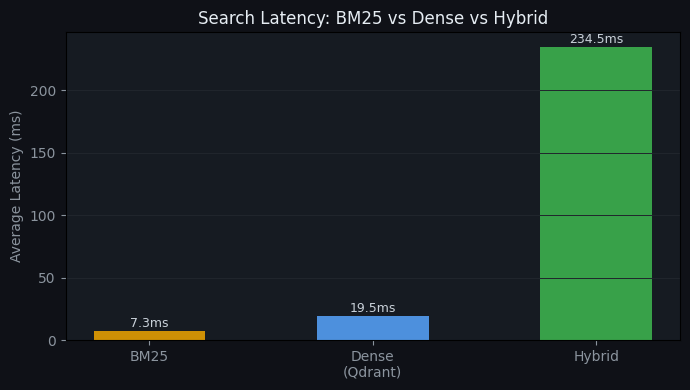

Plot saved.


In [20]:
methods = ['BM25', 'Dense\n(Qdrant)', 'Hybrid']
latencies = [bm25_lat, dense_lat, hybrid_lat]
colors_bar = ['#f0a500', '#58a6ff', '#3fb950']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(methods, latencies, color=colors_bar, alpha=0.85, width=0.5)
for bar, val in zip(bars, latencies):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}ms', ha='center', va='bottom',
            color='#c9d1d9', fontsize=9)
ax.set_ylabel('Average Latency (ms)')
ax.set_title('Search Latency: BM25 vs Dense vs Hybrid', color='#e6edf3')
ax.grid(True, axis='y', color='#21262d', linewidth=0.7)
plt.tight_layout()
plt.savefig('../outputs/latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

### Plot: Score Comparison Across Methods

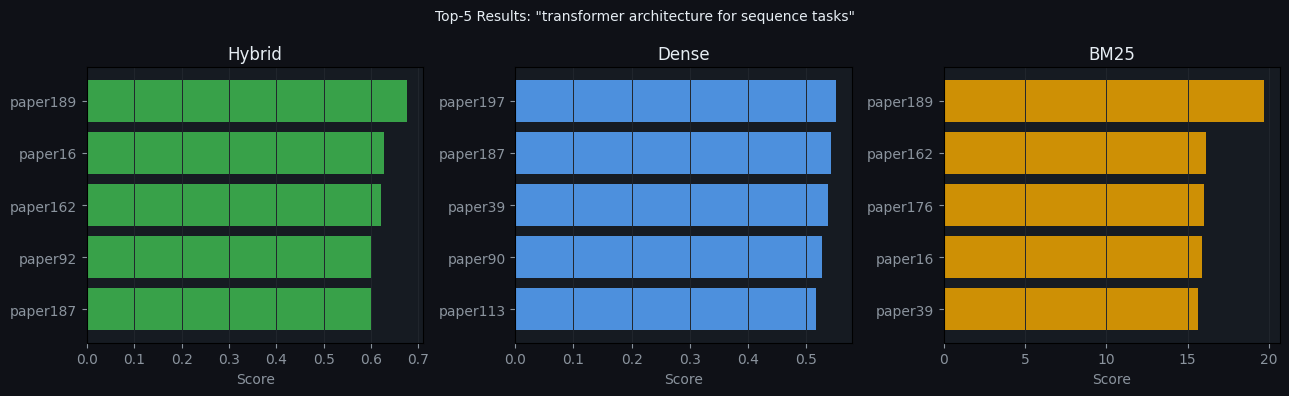

Plot saved.


In [21]:
query = TEST_QUERIES[0]
h_results = hybrid_search(query, top_k=5)
d_results = dense_search(query,  top_k=5)
b_results = bm25_search(query,   top_k=5)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, results, title, color in zip(
    axes,
    [h_results, d_results, b_results],
    ['Hybrid', 'Dense', 'BM25'],
    ['#3fb950', '#58a6ff', '#f0a500']
):
    labels = [r['paper_id'] for r in results]
    scores = [r['score']    for r in results]
    ax.barh(labels[::-1], scores[::-1], color=color, alpha=0.85)
    ax.set_title(title, color='#e6edf3')
    ax.set_xlabel('Score')
    ax.grid(True, axis='x', color='#21262d', linewidth=0.7)

fig.suptitle(f'Top-5 Results: "{query}"', color='#e6edf3', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/score_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## Summary

In [22]:
info = qdrant.get_collection(COLLECTION_NAME)

print('=' * 55)
print('  SEMANTIC RETRIEVAL COMPLETE')
print('=' * 55)
print(f'  Chunks embedded       : {len(chunks)}')
print(f'  Embedding model       : all-MiniLM-L6-v2')
print(f'  Embedding dimension   : {VECTOR_DIM}')
print(f'  Vectors in Qdrant     : {info.points_count}')
print(f'  Search methods        : BM25, Dense, Hybrid')
print(f'  Hybrid alpha          : 0.5 (equal weight)')
print(f'  BM25 latency          : {bm25_lat:.1f} ms')
print(f'  Dense latency         : {dense_lat:.1f} ms')
print(f'  Hybrid latency        : {hybrid_lat:.1f} ms')
print('=' * 55)
print()
print('Key improvement over D1 TF-IDF:')
print('  Dense embeddings capture semantic meaning')
print('  e.g. "deep learning" matches "neural networks"')
print('  Hybrid combines lexical + semantic for best results')

  SEMANTIC RETRIEVAL COMPLETE
  Chunks embedded       : 6728
  Embedding model       : all-MiniLM-L6-v2
  Embedding dimension   : 384
  Vectors in Qdrant     : 6728
  Search methods        : BM25, Dense, Hybrid
  Hybrid alpha          : 0.5 (equal weight)
  BM25 latency          : 7.3 ms
  Dense latency         : 19.5 ms
  Hybrid latency        : 234.5 ms

Key improvement over D1 TF-IDF:
  Dense embeddings capture semantic meaning
  e.g. "deep learning" matches "neural networks"
  Hybrid combines lexical + semantic for best results
